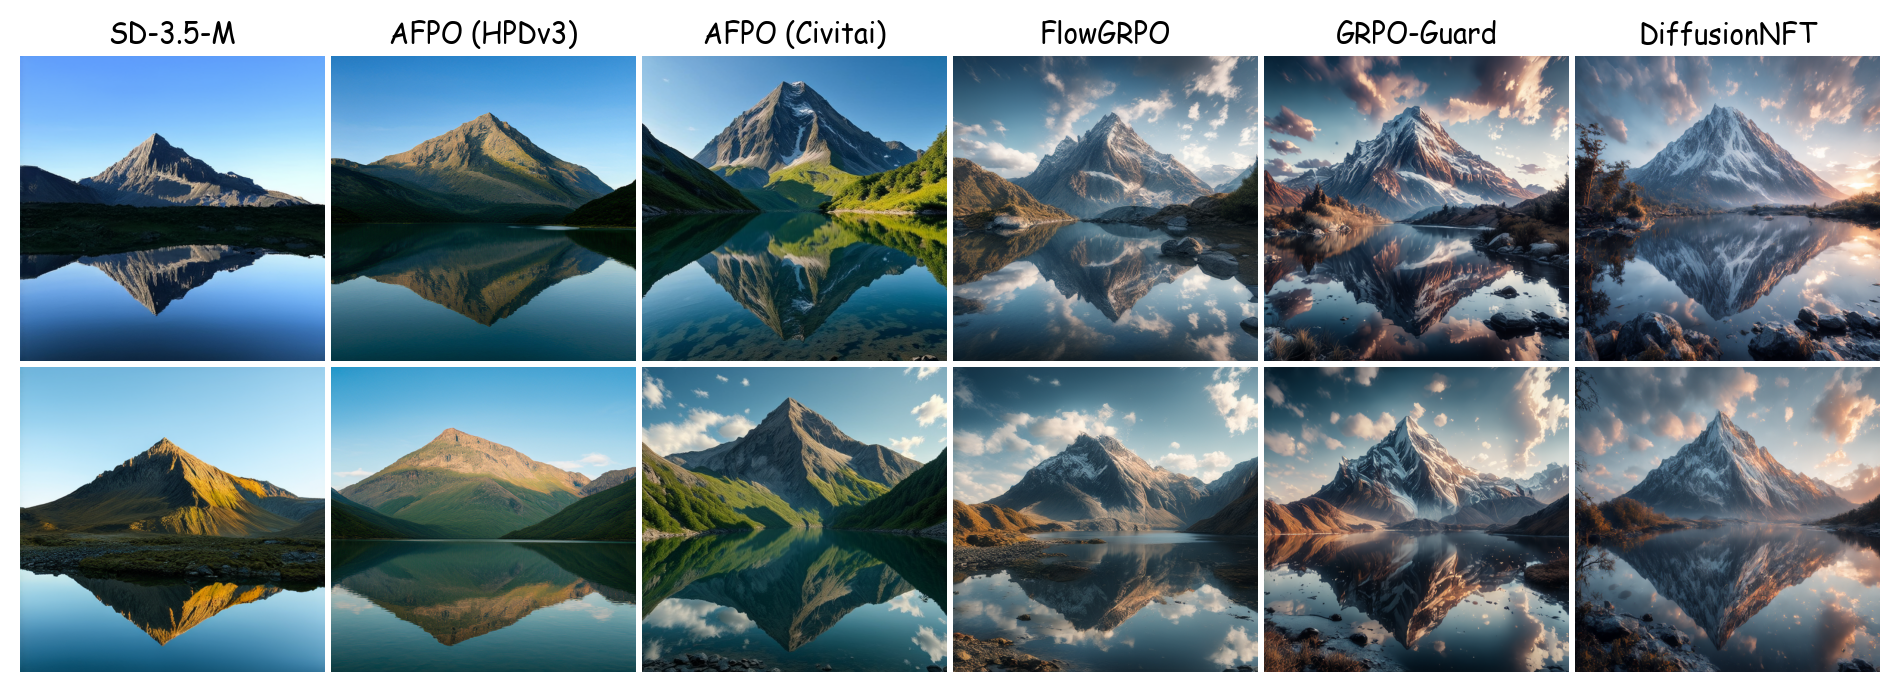

In [8]:
### SD-3.5-Medium visualization ###
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from matplotlib.font_manager import FontProperties

comic_font = FontProperties(
    fname="/data3/chenweiyan/notebook/fine-tune-diffusion/spo_gitee/notebook/visualization/Comic Sans MS.ttf",
    size=10
)


base_image_dir=f"/data_center/data2/dataset/chenwy/21164-data/diffusion-dpo/sd-3-5-medium"

method_list = [
    "sd-3-5-medium",
    "irl_top_512_images_no_anime_colorfulness_pickscore_0.02-hpdv3_all_lr_0.0002_ckpt_3200-dpo_top_512_images_no_anime_colorfulness_pickscore_0.02-hpdv3_all",
    "irl-top_512_images_pickscore_002-civitai_top_sfw_images-uids_lr_0.0002_ckpt_3200-dpo_top_512_images_pickscore_002-civitai_top_sfw_images-uids",
    "FlowGRPO-PickScore",
    "GRPO-Guard",
    "DiffusionNFT",
]
method_name_list = [
    "SD-3.5-M",
    "AFPO (HPDv3)",
    "AFPO (Civitai)",
    "FlowGRPO",
    "GRPO-Guard",
    "DiffusionNFT"
]
ckpt_list = [ 0, 450, 400, 0, 0, 0]
dataset_name = "partiprompts"  # 选择一个 dataset_name，因为所有图片都是同一个 image_id
image_id = 489
seed_list = [42, 123,]  # 定义多个 seed，每一行对应一个 seed
num_rows = len(seed_list)
num_columns = len(method_list)

fig, axes = plt.subplots(num_rows, num_columns, figsize=(2 * num_columns, 2 * num_rows), dpi=200)

if num_rows == 1:
    axes = [axes]
if num_columns == 1:
    axes = [axes]

# 外层循环：不同的 seed（行）
for row_idx, seed in enumerate(seed_list):
    # 内层循环：不同的方法（列）
    for col_idx, (method, ckpt, method_name) in enumerate(zip(method_list, ckpt_list, method_name_list)):
        image_path = os.path.join(base_image_dir, f"generate_images_seed_{seed}/{dataset_name}", method, f"ckpt-{ckpt}", "images", f"{image_id:05d}.png")
        img = mpimg.imread(image_path)
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].axis('off')
        
        # 第一行显示方法名称作为列标题
        if row_idx == 0:
            axes[row_idx][col_idx].set_title(method_name, pad=5, fontproperties=comic_font)
        
        # 第一列显示 seed 作为行标签（可选）
        if col_idx == 0:
            axes[row_idx][col_idx].set_ylabel(f'Seed {seed}', fontproperties=comic_font, rotation=90, va='center')

plt.subplots_adjust(wspace=0.02, hspace=0.02)
# plt.tight_layout()
# plt.savefig('SD-3-5-Medium-visualization.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.show()
